In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

Task 1 — Read and Display Image

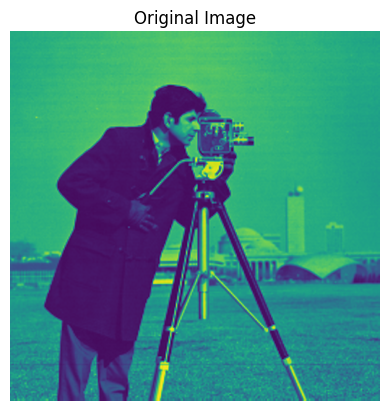

In [ ]:
# image path
image_path = "/content/cameraman.png"

# open image using PIL
image = Image.open(image_path)

# display image
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

Task 2 — Show Top-Left 100×100 Pixels

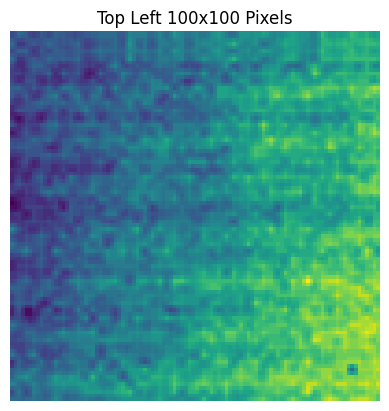

In [ ]:
img_array = np.array(image)

# extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.axis("off")
plt.title("Top Left 100x100 Pixels")
plt.show()

Task 3 — Show RGB Channels

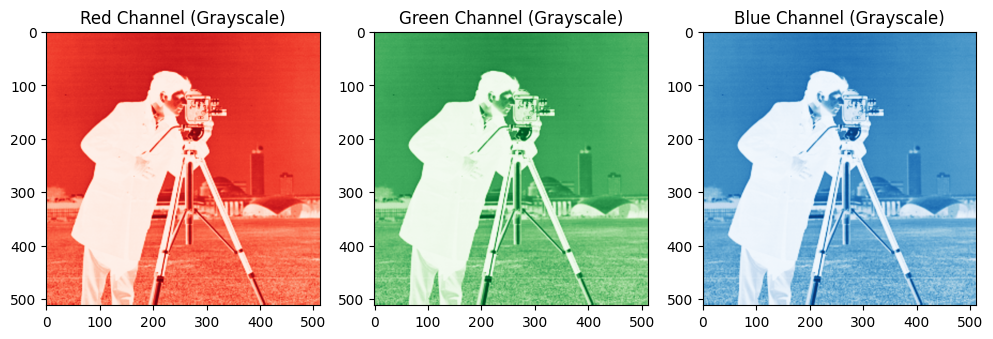

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_array, cmap="Reds")
plt.title("Red Channel (Grayscale)")

plt.subplot(1,3,2)
plt.imshow(img_array, cmap="Greens")
plt.title("Green Channel (Grayscale)")

plt.subplot(1,3,3)
plt.imshow(img_array, cmap="Blues")
plt.title("Blue Channel (Grayscale)")

plt.show()

**Exercise 2 Tasks**

Task 1 — Load and Display a Grayscale Image

height and width: 512 512


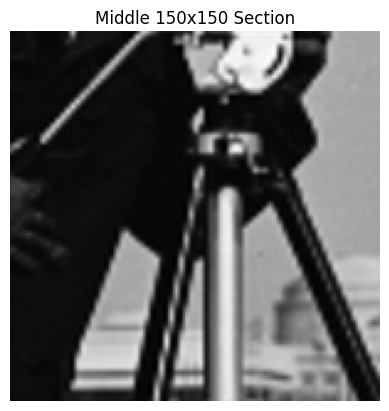

In [ ]:
img_array = np.array(image)

h, w= img_array.shape
print("height and width:", h, w)

center_crop = img_array[
    h//2 - 75 : h//2 + 75,
    w//2 - 75 : w//2 + 75
]

plt.imshow(center_crop, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

Task 3 — Apply Threshold

Threshold rule:

pixel < 100 → 0
pixel ≥ 100 → 255

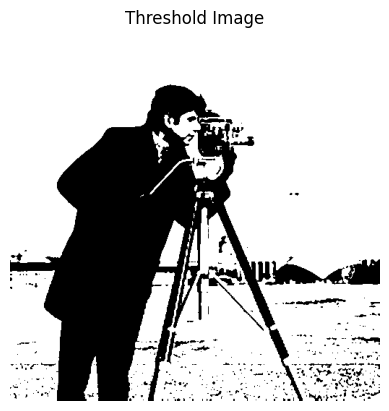

In [ ]:
threshold = img_array.copy()

threshold[threshold < 100] = 0
threshold[threshold >= 100] = 255

plt.imshow(threshold, cmap="gray")
plt.title("Threshold Image")
plt.axis("off")
plt.show()

Task 4 — Rotate Image 90° Clockwise

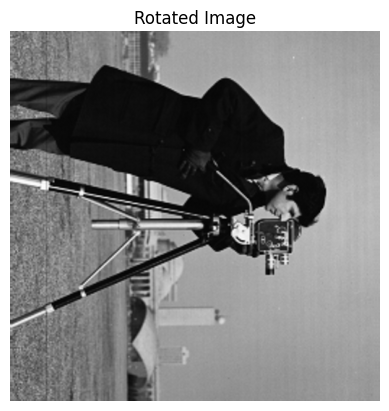

In [ ]:
rotated = np.rot90(img_array, -1)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

Task 5 — Convert Grayscale → RGB

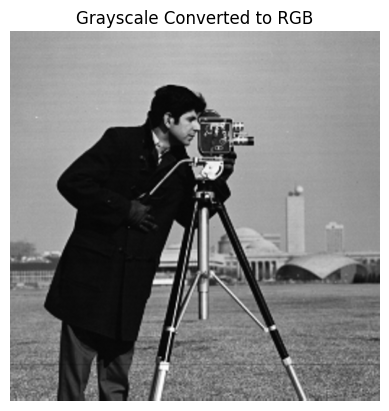

In [ ]:
rgb_image = np.stack((img_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

Exercise 3 — Image Compression and Decompression Using PCA.

Build a PCA algorithm from scratch using the explained variance method for image compression.

1️. Load and Prepare Data

Load an image of your choice

If the image is color → convert it to grayscale

Center / Standardize the data

Compute the covariance matrix


2️. Eigen Decomposition

Compute eigenvalues

Compute eigenvectors

Sort eigenvalues in descending order

Select the top k principal components

Use cumulative explained variance to decide k


3️. Reconstruction and Experiment

Project the image to the lower-dimensional space

Reconstruct the image

Experiment with different numbers of principal components

Compare results

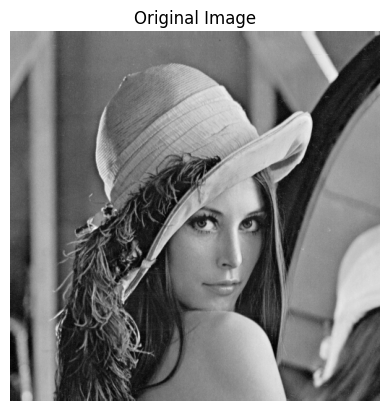

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
image_path = "/content/lena_gray.gif"
image = Image.open(image_path).convert("L")

img = np.array(image)

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()




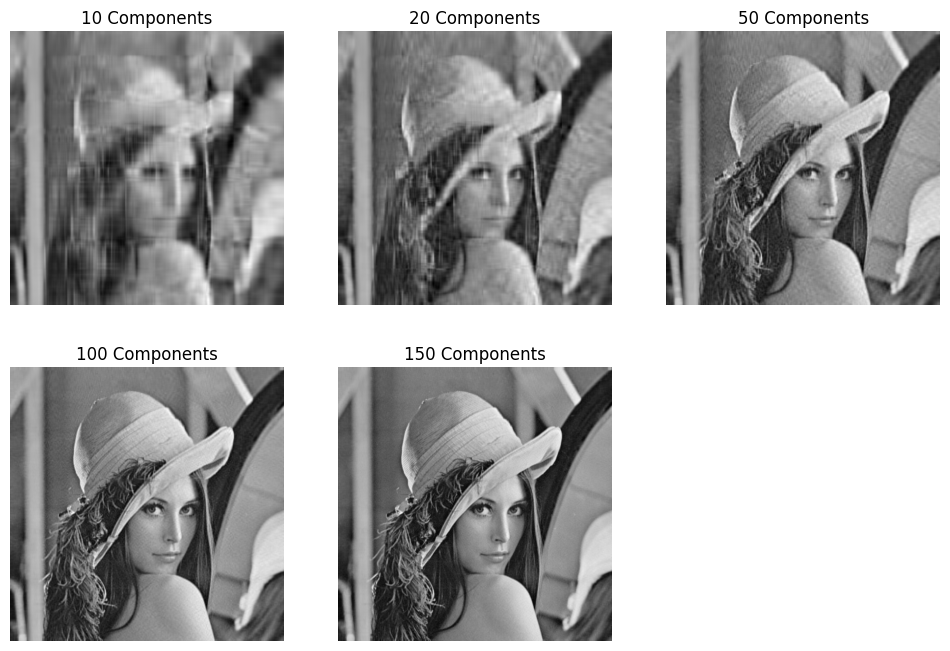

In [ ]:
#1. Center the Data
mean = np.mean(img, axis=0)
centered = img - mean


#2. Covariance Matrix
cov_matrix = np.cov(centered, rowvar=False)


#3. Eigen Decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)


#4. Sort Eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]


#5. PCA Reconstruction Function
def reconstruct_image(k):

    components = eigenvectors[:, :k]

    projection = np.dot(centered, components)

    reconstruction = np.dot(projection, components.T) + mean

    return reconstruction


#6. Experiment with different k
ks = [10, 20, 50, 100, 150]

plt.figure(figsize=(12,8))

for i, k in enumerate(ks):

    plt.subplot(2,3,i+1)

    img_reconstructed = reconstruct_image(k)

    plt.imshow(img_reconstructed, cmap="gray")

    plt.title(f"{k} Components")

    plt.axis("off")

plt.show()